# Setup

In [1]:
import datasets
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from google.colab import drive, userdata
from huggingface_hub import login, hf_hub_download

cache_path = "/content/huggingface_cache"
os.makedirs(cache_path, exist_ok=True)
os.environ['HF_HOME'] = cache_path

if userdata.get('HF_TOKEN'):
  login(token=userdata.get('HF_TOKEN'))
  hf_hub_download(repo_id="sookiemonster/asrs-narratives", filename="utils.py", repo_type="dataset",local_dir=".")

raw_dataset = datasets.load_dataset("sookiemonster/asrs-narratives")

utils.py: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/9.74M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/4.09M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.38M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10360 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4441 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9868 [00:00<?, ? examples/s]

In [2]:
train_ds = raw_dataset['train']
valid_ds = raw_dataset['validation']
test_ds = raw_dataset['test']

labels = train_ds.features['label'].names

id_to_label = { idx : label for idx, label in enumerate(labels) }
label_to_id = { label : idx for idx, label in id_to_label.items() }

In [3]:
from functools import partial

def filter_labels(ds, to_remove:list):
  to_remove_set = set(to_remove)
  return ds.filter(lambda example : id_to_label[example['label']] not in to_remove_set)

filter_ambiguous = partial(filter_labels, to_remove=['ambiguous'])

filtered_train_ds = filter_ambiguous(train_ds)
filtered_valid_ds = filter_ambiguous(valid_ds)
filtered_test_ds = filter_ambiguous(test_ds)

Filter:   0%|          | 0/10360 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4441 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9868 [00:00<?, ? examples/s]

In [4]:
df = filtered_train_ds.to_pandas()
df.label = df.label.map(id_to_label)
df[df.label == 'humanfactors']

,acn,text,label
1,2109432,Narrative 1 - 'Wheelchair battery form and pro...,humanfactors
2,1974739,Narrative 1 - 'The aircraft at some point in t...,humanfactors
9,2232811,Narrative 1 - 'I was simulating a XC flight to...,humanfactors
12,2205943,Narrative 1 - 'During our arrival into ZZZ we ...,humanfactors
13,2195845,Narrative 1 - 'Prior to departure checked for ...,humanfactors
...,...,...,...
9508,2088537,Narrative 1 - 'Upon reaching Location X; we tr...,humanfactors
9509,2237828,Narrative 1 - 'Agent working in the bagroom; b...,humanfactors
9513,1891350,Narrative 1 - 'Aircraft was operating on an IF...,humanfactors
9514,2144248,Narrative 1 - 'We were coming into BZM; winds ...,humanfactors


In [5]:
from datasets import concatenate_datasets
ds = concatenate_datasets([raw_dataset['train'], raw_dataset['validation'], raw_dataset['test']])
ds.to_pandas()['label'].map(id_to_label).value_counts().to_csv("prop.csv")
ds.to_pandas()['label'].map(id_to_label).value_counts()

,count
label,
humanfactors,8427
aircraft,8272
procedure,2418
ambiguous,1989
weather,823
airport,610
environment-nonweatherrelated,595
chartorpublication,336
airspacestructure,322


In [6]:
def _validate_groupings(groupings:dict[str, set]):
  mut_excl = [va.isdisjoint(vb) for ka, va in groupings.items() for kb, vb in groupings.items() if ka != kb]
  assert all(mut_excl), f"{mut_excl}"

  all_labels = set([label for val_set in groupings.values() for label in val_set])
  assert all_labels == set(id_to_label.values()), f"Missing: {set(id_to_label.values()) - all_labels}"


def group_labels(ds, groupings:dict[str, set]):
  _validate_groupings(groupings)
  group_names = list(groupings.keys())
  group_names.sort()

  fine_grained_label_to_group = {
      label : group_name for group_name, val_set in groupings.items() for label in val_set
  }

  res = ds.map(lambda ex: {"group" : fine_grained_label_to_group[ id_to_label[ex['label']] ]})
  res = res.filter(lambda ex: ex["group"] != 'DELETE')

  new_features = res.features.copy()
  group_names.remove("DELETE")
  new_features["group"] = ClassLabel(names=group_names)

  res = res.cast(new_features)
  return res

# Fine-Tuning Setup

In [7]:
import torch
import sys

print(f"Python Version: {sys.version_info.major}.{sys.version_info.minor}")
print(f"PyTorch Version: {torch.__version__.split('+')[0]}")
print(f"CUDA Version (Torch): {torch.version.cuda}")
print(f"CXX11 ABI: {torch._C._GLIBCXX_USE_CXX11_ABI}")

Python Version: 3.12
PyTorch Version: 2.10.0
CUDA Version (Torch): 12.8
CXX11 ABI: True


In [ ]:
!pip install "https://github.com/lesj0610/flash-attention/releases/download/v2.8.3-cu12-torch2.10-cp312/flash_attn-2.8.3%2Bcu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.6/253.6 MB 7.7 MB/s eta 0:00:00


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00


In [7]:
from datasets import ClassLabel

groupings = {
    'DELETE' : set(['ambiguous']),
    'ac' : set(['aircraft']),
    'weather' : set(['weather']),
    'hf-proc' : set(['humanfactors', 'procedure']),
    'rest' : set(id_to_label.values()) - set(['humanfactors', 'procedure', 'aircraft', 'weather', 'ambiguous'])
}

grouped_ds_train = group_labels(filtered_train_ds, groupings)
grouped_ds_valid = group_labels(filtered_valid_ds, groupings)
grouped_ds_test = group_labels(filtered_test_ds, groupings)

Map:   0%|          | 0/9525 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9525 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/9525 [00:00<?, ? examples/s]

Map:   0%|          | 0/4083 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4083 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4083 [00:00<?, ? examples/s]

Map:   0%|          | 0/9072 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9072 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/9072 [00:00<?, ? examples/s]

In [12]:
id_to_group = { idx : val for idx, val in enumerate(grouped_ds_train.features['group'].names) }

# Utils

In [49]:
import torch
from tqdm import tqdm
from transformers import pipeline

class AggregateModel:
  @staticmethod
  def load_model(model_id):
    pipe = pipeline(
        "text-classification",
        model=model_id,
        device=torch.device('cuda'),
        # dtype=torch.bfloat16,
        dtype=torch.float16,
    )
    return pipe


  @staticmethod
  def add_prefix(ds:datasets):

    PREFIX = "classification: "
    res = ds.map(lambda examples : {"text" : PREFIX + examples["text"]})

    return res

  def __init__(self):
    self.l1_binary_aircraft_id = 'sookiemonster/asrs-modernbert-aircraft-vs-rest'
    self.l2_binary_weather_id = 'sookiemonster/asrs-modernbert-l2-weather-mini-batch'
    self.l3_binary_hf_proc_id = 'sookiemonster/asrs-modernbert-l3-hf-proc_v2'

    self.l1_stop_labels = set(['ac'])
    self.l2_stop_labels = set(['weather'])
    self.l3_stop_labels = set(['hf-proc'])

    self.rounds = [
        { "mdl" : self.l1_binary_aircraft_id, "stop" : self.l1_stop_labels },
        { "mdl" : self.l2_binary_weather_id, "stop" : self.l2_stop_labels },
        { "mdl" : self.l3_binary_hf_proc_id, "stop" : self.l3_stop_labels }
    ]

  def fetch_models(self):
    for r in self.rounds:
      print("Loading model: ", r['mdl'])
      AggregateModel.load_model(r['mdl'])

  def predict(self, ds, reload=True):
    if reload:
      self.fetch_models()

    pre_ds = AggregateModel.add_prefix(ds)

    df = ds.to_pandas().set_index('acn')
    all_pred = { acn : np.nan for acn in df.index}
    all_scores = { acn : 0 for acn in df.index }

    for round in self.rounds:
      print("Starting round", round)

      model_id = round['mdl']
      stop_labels = round['stop']

      # Get all entries that weren't classified yet
      prev = pd.Series(all_pred)
      unclassified = set(prev[pd.isna(prev)].index)

      to_predict = df[df.index.isin(unclassified)].copy()
      to_predict_texts = to_predict['text'].to_list()

      # print("Previewing unclassified snippet...")
      # display(to_predict.head())

      print("Predicting on ", len(to_predict_texts), " instances.")

      pipe = AggregateModel.load_model(model_id)
      pred = []
      scores = []
      for text in tqdm(to_predict_texts):
        output = pipe(text)[0]
        # print(output)
        pred.append(output['label'])
        scores.append(output['score'])

      # print(np.array(pred))
      to_predict['new_pred'] = np.array(pred)
      to_predict['scores'] = np.array(scores)

      num_stopped = 0
      for acn, row in to_predict.iterrows():
        if row['new_pred'] in stop_labels:
          num_stopped += 1
          all_pred[acn] = row['new_pred']
          all_scores[acn] = row['scores']

      print(f"Finished classifying {num_stopped}/{len(to_predict_texts)}(round) / {len(all_pred)} (total)")

    pred_series = pd.Series(all_pred)
    pred_series = pred_series.replace(np.nan, 'rest')
    score_series = pd.Series(all_scores)

    res = pd.concat([pred_series, score_series], axis=1)
    return res

mdl = AggregateModel()

In [26]:
sub = grouped_ds_valid.select(range(50))
sub.to_pandas()['label'].map(id_to_label).value_counts()

,count
label,
aircraft,23
humanfactors,19
weather,2
airspacestructure,2
procedure,2
airport,1
environment-nonweatherrelated,1


In [50]:
pred = mdl.predict(grouped_ds_valid, reload=False)

Starting round {'mdl': 'sookiemonster/asrs-modernbert-aircraft-vs-rest', 'stop': {'ac'}}
Predicting on  4083  instances.


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

100%|██████████| 4083/4083 [02:24<00:00, 28.35it/s]


Finished classifying 1399/4083(round) / 4083 (total)
Starting round {'mdl': 'sookiemonster/asrs-modernbert-l2-weather-mini-batch', 'stop': {'weather'}}
Predicting on  2684  instances.


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

100%|██████████| 2684/2684 [01:43<00:00, 25.99it/s]


Finished classifying 170/2684(round) / 4083 (total)
Starting round {'mdl': 'sookiemonster/asrs-modernbert-l3-hf-proc_v2', 'stop': {'hf-proc'}}
Predicting on  2514  instances.


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

100%|██████████| 2514/2514 [01:27<00:00, 28.58it/s]


Finished classifying 1867/2514(round) / 4083 (total)


In [51]:
pred.to_csv("l3_valid_predictions.csv")

In [52]:
pred

,0,1
2018769,weather,0.727685
2185235,hf-proc,0.737820
2156158,ac,0.855972
2139473,ac,0.979215
1813457,ac,0.617051
...,...,...
2153249,ac,0.993049
1895387,rest,0.000000
1939197,hf-proc,0.651743
2074236,hf-proc,0.960063


## Eval on Validation

In [27]:
pred = pd.read_csv("l3_valid_predictions.csv", index_col=0, names=['prediction', 'confidence'], skiprows=1)
pred

,prediction,confidence
2018769,weather,0.727685
2185235,hf-proc,0.737820
2156158,ac,0.855972
2139473,ac,0.979215
1813457,ac,0.617051
...,...,...
2153249,ac,0.993049
1895387,rest,0.000000
1939197,hf-proc,0.651743
2074236,hf-proc,0.960063


              precision    recall  f1-score   support

          ac       0.88      0.83      0.86      1489
     hf-proc       0.83      0.80      0.81      1952
        rest       0.50      0.65      0.56       494
     weather       0.69      0.79      0.74       148

    accuracy                           0.79      4083
   macro avg       0.73      0.77      0.74      4083
weighted avg       0.81      0.79      0.80      4083



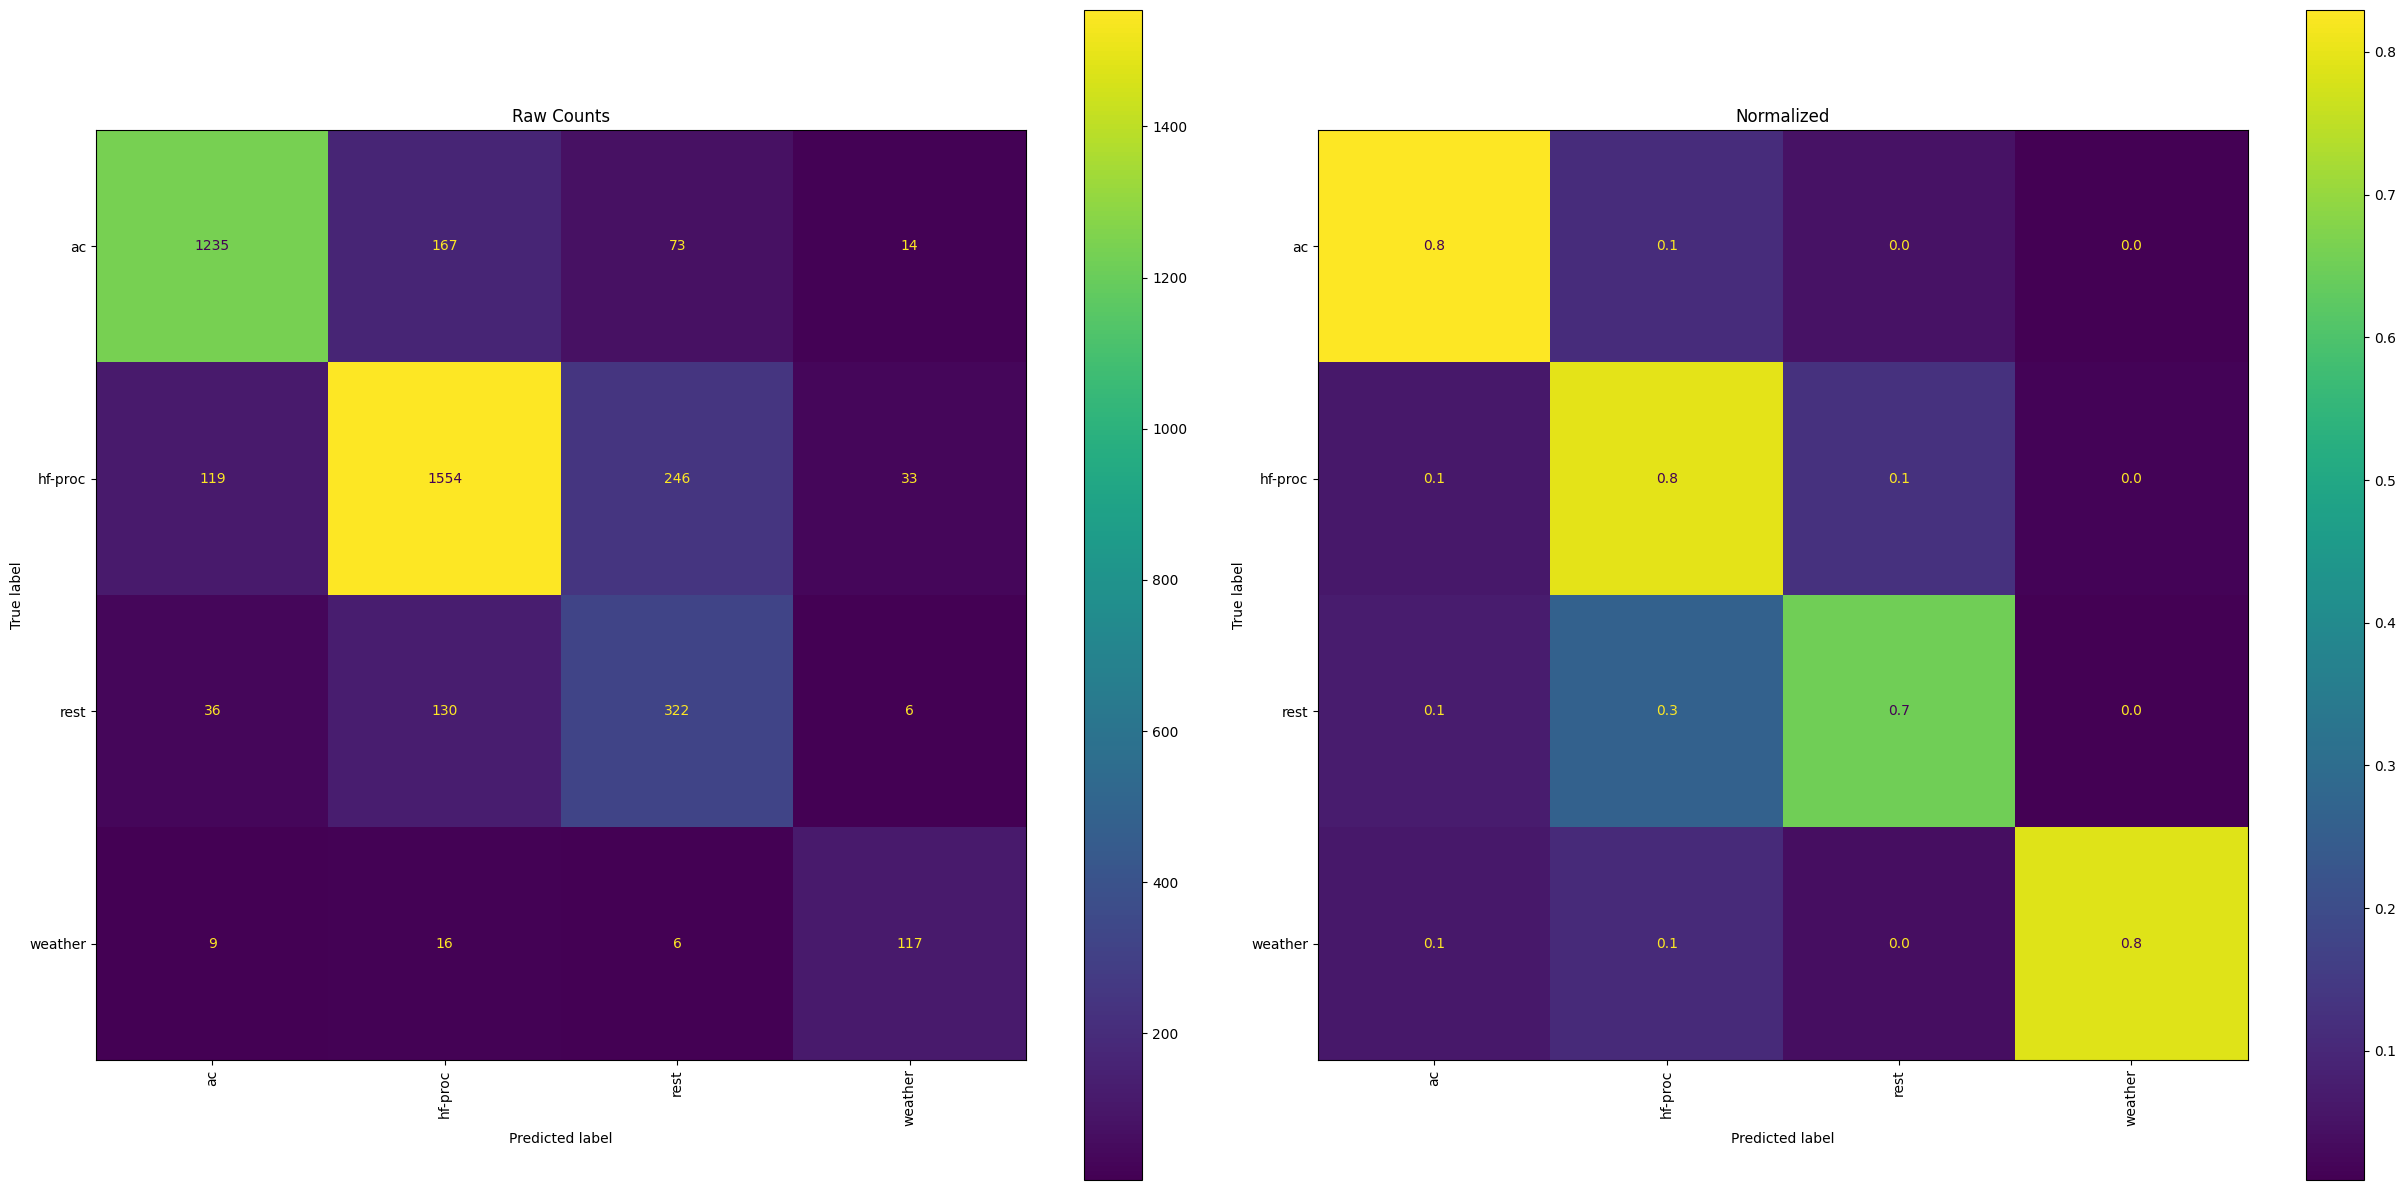

In [29]:
from utils import visualize_eval

y_true = grouped_ds_valid.to_pandas()['group'].map(id_to_group)
y_pred = pred['prediction']
visualize_eval(y_true=y_true, pred=y_pred, label="L3 Evaluation (Validation)")